In [1]:
from a3em.datasets import arden
import os
from pathlib import Path

In [2]:
prefetch_path = Path(os.getenv('PREFETCH_PATH'))
X_train, X_test, y_train, y_test = arden.load_data(prefetch_path, random_state=123)

prefetching data...
local data found


In [3]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
136,41.015625,153.136708,130.196789,22.460938,224.609375,-285.532080,217.538460,-14.689281,21.197130,1.626396,...,0.001911,0.001241,0.000612,0.000274,0.000153,0.000049,0.000024,0.000005,6.958492e-07,7.626961e-08
23,33.203125,175.732140,138.983313,20.507812,262.695312,-114.068183,216.291654,-33.977207,38.213150,-25.812116,...,0.032434,0.022124,0.012285,0.006626,0.003601,0.001523,0.000619,0.000218,8.117067e-05,4.119945e-05
125,25.390625,136.140110,118.189398,24.414062,123.046875,-212.728818,216.290165,-3.622066,32.242136,1.382238,...,0.003195,0.001843,0.000936,0.000493,0.000262,0.000135,0.000054,0.000016,3.608993e-06,1.050581e-06
128,38.085938,196.402151,147.113302,32.226562,283.203125,-181.294940,203.188356,-39.440637,31.487898,-27.129474,...,0.015764,0.008060,0.005136,0.003597,0.001974,0.000999,0.000365,0.000091,1.592795e-05,1.745662e-06
93,25.390625,109.796667,91.474899,24.414062,112.304688,-260.057713,218.994703,28.280906,26.499594,23.025403,...,0.000767,0.000475,0.000294,0.000146,0.000070,0.000034,0.000016,0.000006,2.798236e-06,2.101497e-06


In [4]:
y_train.head()

136    0
23     0
125    1
128    0
93     1
Name: label, dtype: int64

In [5]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [6]:
import pandas as pd

In [7]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [8]:
labels_aggregate['label'].value_counts()

label
1    184
0    179
Name: count, dtype: int64

In [9]:
# Combine
df = train_features.copy().drop(columns=['Unnamed: 0'])
df['label'] = train_labels['label']

In [10]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,41.015625,153.136708,130.196789,22.460938,224.609375,-285.532080,217.538460,-14.689281,21.197130,1.626396,...,0.001241,0.000612,0.000274,0.000153,0.000049,0.000024,0.000005,6.958492e-07,7.626961e-08,0
1,33.203125,175.732140,138.983313,20.507812,262.695312,-114.068183,216.291654,-33.977207,38.213150,-25.812116,...,0.022124,0.012285,0.006626,0.003601,0.001523,0.000619,0.000218,8.117067e-05,4.119945e-05,0
2,25.390625,136.140110,118.189398,24.414062,123.046875,-212.728818,216.290165,-3.622066,32.242136,1.382238,...,0.001843,0.000936,0.000493,0.000262,0.000135,0.000054,0.000016,3.608993e-06,1.050581e-06,1
3,38.085938,196.402151,147.113302,32.226562,283.203125,-181.294940,203.188356,-39.440637,31.487898,-27.129474,...,0.008060,0.005136,0.003597,0.001974,0.000999,0.000365,0.000091,1.592795e-05,1.745662e-06,0
4,25.390625,109.796667,91.474899,24.414062,112.304688,-260.057713,218.994703,28.280906,26.499594,23.025403,...,0.000475,0.000294,0.000146,0.000070,0.000034,0.000016,0.000006,2.798236e-06,2.101497e-06,1


### Compute Summary Statistics

In [11]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,34.736690,24.884523,9.976545,2.984471
centroid,170.609739,118.637574,24.761013,10.785884
bandwidth,137.131445,99.210284,13.684232,9.927211
freq_5,23.003472,23.722628,6.216142,2.082273
freq_95,252.495660,121.179288,59.320771,6.338231
mfcc_1,-212.651416,-263.732546,84.238527,31.554324
mfcc_2,209.374589,218.258747,13.202311,7.285560
mfcc_3,-22.941539,23.574862,21.141851,14.327257
mfcc_4,29.709438,23.369145,7.579856,5.857031
mfcc_5,-15.821549,18.092906,11.631314,7.905653


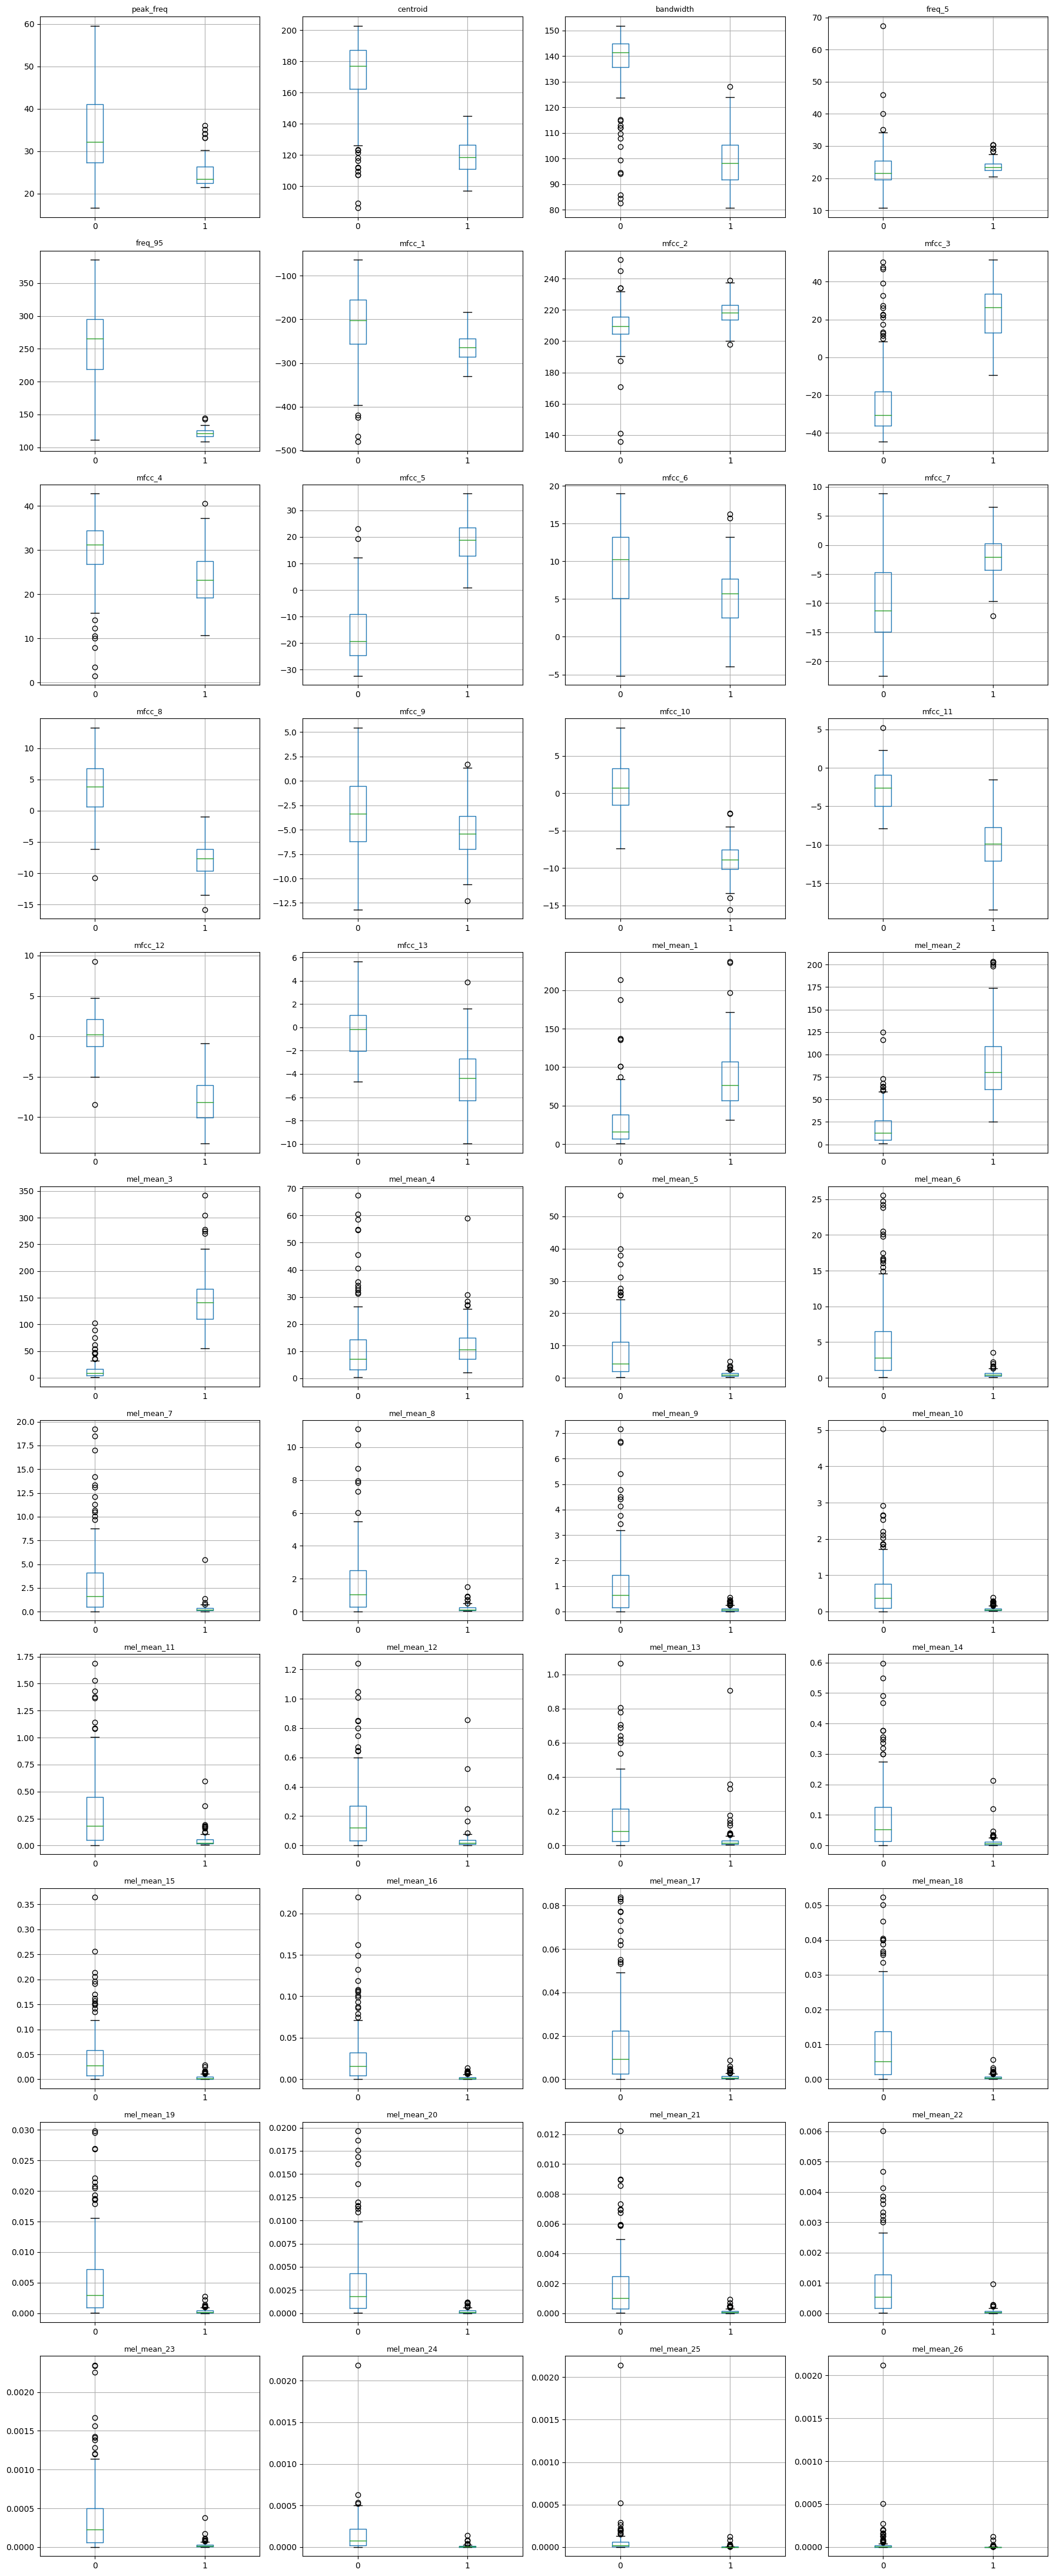

In [12]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [13]:
from scipy.stats import mannwhitneyu

In [14]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [15]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
20,mel_mean_3,44.0,1.092038e-45
14,mfcc_10,18382.0,4.948211e-45
16,mfcc_12,18276.0,4.931892e-44
12,mfcc_8,18254.0,7.921673e-44
4,freq_95,18151.0,6.872965e-43
9,mfcc_5,352.0,8.503702e-43
15,mfcc_11,17839.0,4.874244e-40
19,mel_mean_2,722.0,1.880244e-39
2,bandwidth,17702.0,7.942301e-39
1,centroid,17327.0,1.315401e-35


In [16]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
20,mel_mean_3,44.0,1.092038e-45,True
14,mfcc_10,18382.0,4.948211e-45,True
16,mfcc_12,18276.0,4.931892e-44,True
12,mfcc_8,18254.0,7.921673e-44,True
4,freq_95,18151.0,6.872965e-43,True
9,mfcc_5,352.0,8.503702e-43,True
15,mfcc_11,17839.0,4.874244e-40,True
19,mel_mean_2,722.0,1.880244e-39,True
2,bandwidth,17702.0,7.942301e-39,True
1,centroid,17327.0,1.315401e-35,True


In [17]:
results["Significant"].value_counts()

Significant
True    44
Name: count, dtype: int64

In [18]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [19]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [20]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(272, 44)
(91, 44)
label
1    137
0    135
Name: count, dtype: int64
label
1    47
0    44
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[43  1]
 [ 1 46]]


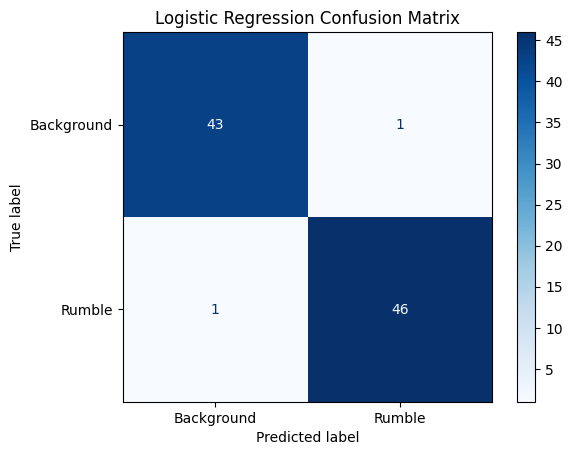

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        44
           1       0.98      0.98      0.98        47

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



In [27]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.993


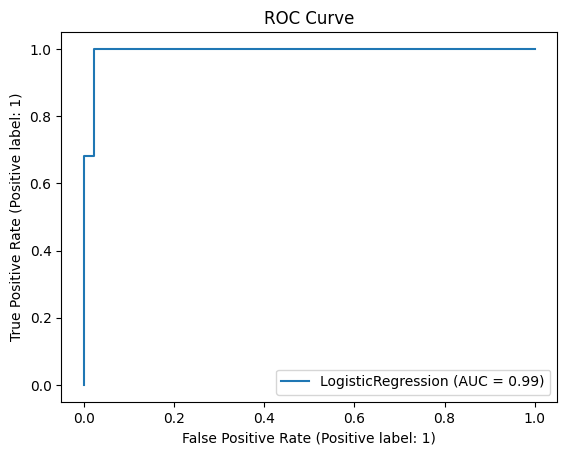

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [29]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
20,mel_mean_3,1.044961,1.044961
12,mfcc_8,-0.922972,0.922972
14,mfcc_10,-0.835988,0.835988
0,peak_freq,-0.807148,0.807148
4,freq_95,-0.673546,0.673546
13,mfcc_9,-0.629109,0.629109
5,mfcc_1,0.616431,0.616431
15,mfcc_11,-0.598150,0.598150
9,mfcc_5,0.580623,0.580623
18,mel_mean_1,0.461333,0.461333


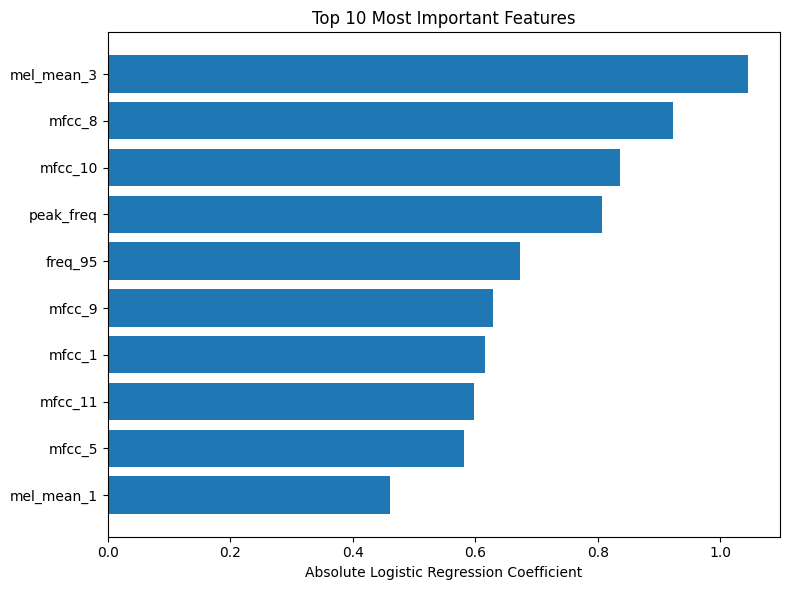

In [30]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,mel_mean_3,1.044961,1.044961,44.0,1.092038e-45,True,4.804966e-44,True
1,mfcc_8,-0.922972,0.922972,18254.0,7.921673e-44,True,8.713840e-43,True
2,mfcc_10,-0.835988,0.835988,18382.0,4.948211e-45,True,1.088606e-43,True
3,peak_freq,-0.807148,0.807148,15599.0,9.119435e-23,True,1.337517e-22,True
4,freq_95,-0.673546,0.673546,18151.0,6.872965e-43,True,6.048210e-42,True
5,mfcc_9,-0.629109,0.629109,12079.0,1.274871e-05,True,1.335579e-05,True
6,mfcc_1,0.616431,0.616431,13667.0,9.592105e-12,True,1.055132e-11,True
7,mfcc_11,-0.598150,0.598150,17839.0,4.874244e-40,True,3.063811e-39,True
8,mfcc_5,0.580623,0.580623,352.0,8.503702e-43,True,6.236048e-42,True
9,mel_mean_1,0.461333,0.461333,1830.0,2.817294e-30,True,1.033008e-29,True


### Cross Validation with Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [34]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        44
           1       0.98      0.98      0.98        47

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



### RandomForest Feature Importance

In [37]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
20,mel_mean_3,0.151360
14,mfcc_10,0.128477
4,freq_95,0.127661
12,mfcc_8,0.103190
1,centroid,0.069352
9,mfcc_5,0.065667
16,mfcc_12,0.057410
2,bandwidth,0.053249
19,mel_mean_2,0.047259
7,mfcc_3,0.040693


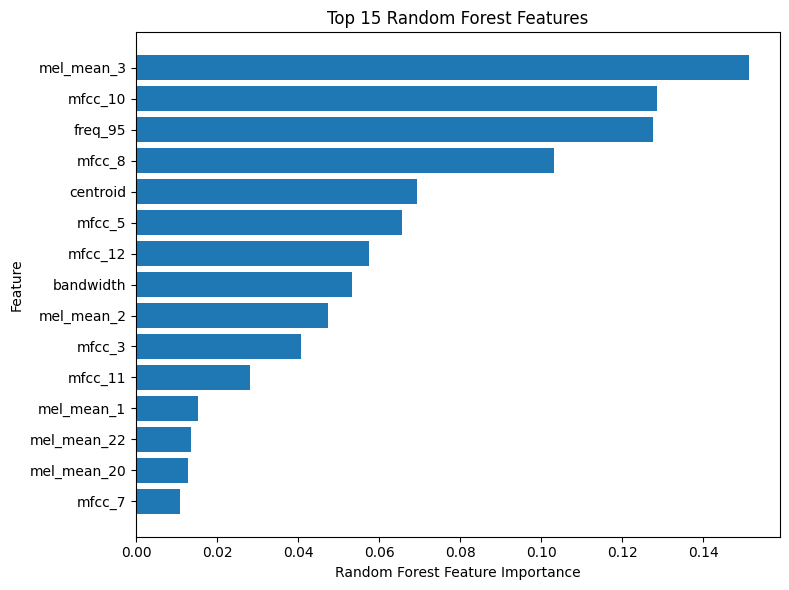

In [38]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [39]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
0,mel_mean_3,1.092038e-45,1.044961,0.151360,1,1,1,1.000000
1,mfcc_10,4.948211e-45,-0.835988,0.128477,2,3,2,2.333333
3,mfcc_8,7.921673e-44,-0.922972,0.103190,4,2,4,3.333333
4,freq_95,6.872965e-43,-0.673546,0.127661,5,5,3,4.333333
5,mfcc_5,8.503702e-43,0.580623,0.065667,6,9,6,7.000000
6,mfcc_11,4.874244e-40,-0.598150,0.028124,7,8,11,8.666667
7,mel_mean_2,1.880244e-39,0.418837,0.047259,8,11,9,9.333333
9,centroid,1.315401e-35,-0.187263,0.069352,10,14,5,9.666667
11,mel_mean_1,2.817294e-30,0.461333,0.015360,12,10,12,11.333333
2,mfcc_12,4.931892e-44,-0.118793,0.057410,3,29,7,13.000000
